In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import re

In [87]:
# Path to MLflow runs folder
import os
MLRUNS_PATH = "/home/28s_mur@lab.graphicon.ru/flow_attack/mlruns/914879025403898454"

# List of specific runs to analyze
SELECTED_RUN_IDS = {"666631270ee649f3a839a103fe4ad84a", "b1fb00728c1c45038b3f387f90335e29",
                    "6d4b028bb76743f08f7647dcea5e902b", "82a687b699a64014ae03ddfe67485e25", "b72bf5dac62e4f56b39069c2c0713e36", "663b2e0affec4567b586a0c074657d62", "2535ff1ca49b4643a524f140b28a5348", "8358097738784107a46e117b4a693571", "3cd9ab1f955640228c0f91ff13e8b504", "343bc5235dd94e1eb9fe9fdf0d4885ff", "5e2a64b70a5b4d32a4b3f6671c7c4f6e", "67d398091fc442a1a60bfa9184a4b6cd", "2c00b5b0acd446d8b487bf3911b6a91a", "954a41397a524020af6560dcb2cca958", "d8eebaaf7f4342c3b9dfab5c27c11b37", "43bce625fa0942aba6d4446f9f212d81"}  # Replace with actual run IDs


def load_mlflow_data(mlruns_path, selected_run_ids=None):
    runs_data = []
    metric_columns = set()  # To track all unique metric names
    param_columns = set()   # To track all unique parameter names
    runs = []  # To store the rows of data

    for root, _, files in os.walk(mlruns_path):
        if "meta.yaml" in files and "metrics" in os.listdir(root):
            run_id = os.path.basename(root)
            if selected_run_ids and run_id not in selected_run_ids:
                continue  # Skip runs not in the selected list

            metrics = {}
            params = {}

            # Load parameters
            params_path = os.path.join(root, "params")
            if os.path.exists(params_path):
                for param_file in os.listdir(params_path):
                    with open(os.path.join(params_path, param_file), "r") as f:
                        params[param_file] = f.read().strip()
                        # Track the parameter name
                        param_columns.add(param_file)

            # Load metrics
            metrics_path = os.path.join(root, "metrics")
            if os.path.exists(metrics_path):
                for metric_file in os.listdir(metrics_path):
                    with open(os.path.join(metrics_path, metric_file), "r") as f:
                        values = [line.split() for line in f.readlines()]
                        # Keep the latest metric value
                        # Last value in the list is the latest
                        latest_value = float(values[-1][1])
                        metrics[metric_file] = latest_value
                        # Track the metric name
                        metric_columns.add(metric_file)

            # Create a row that includes run_id, parameters, and latest metrics
            row = {"run_id": run_id}
            for param_name in param_columns:
                # Use None if the parameter is missing
                row[param_name] = params.get(param_name, None)
            for metric_name in metric_columns:
                # Use None if the metric is missing
                row[metric_name] = metrics.get(metric_name, None)

            runs.append(row)

    # Ensure all rows have consistent columns for both metrics and parameters
    for run in runs:
        # Ensure every row has the same columns for parameters and metrics
        for param_name in param_columns:
            if param_name not in run:
                run[param_name] = None  # Add None for missing parameters
        for metric_name in metric_columns:
            if metric_name not in run:
                run[metric_name] = None  # Add None for missing metrics
    
    return runs



# Load only selected runs
data = pd.DataFrame(load_mlflow_data(MLRUNS_PATH, SELECTED_RUN_IDS))
data['epsilon']
# data[data['run_id'] =='d8eebaaf7f4342c3b9dfab5c27c11b37']['mean_aee_target_attack_step_5']

0     0.00392
1     0.01568
2     0.03137
3     0.03137
4     0.00784
5     0.03137
6     0.00784
7     0.00392
8     0.00784
9     0.01568
10    0.00392
11    0.01568
12    0.03137
13    0.00784
14    0.00392
15    0.01568
Name: epsilon, dtype: object

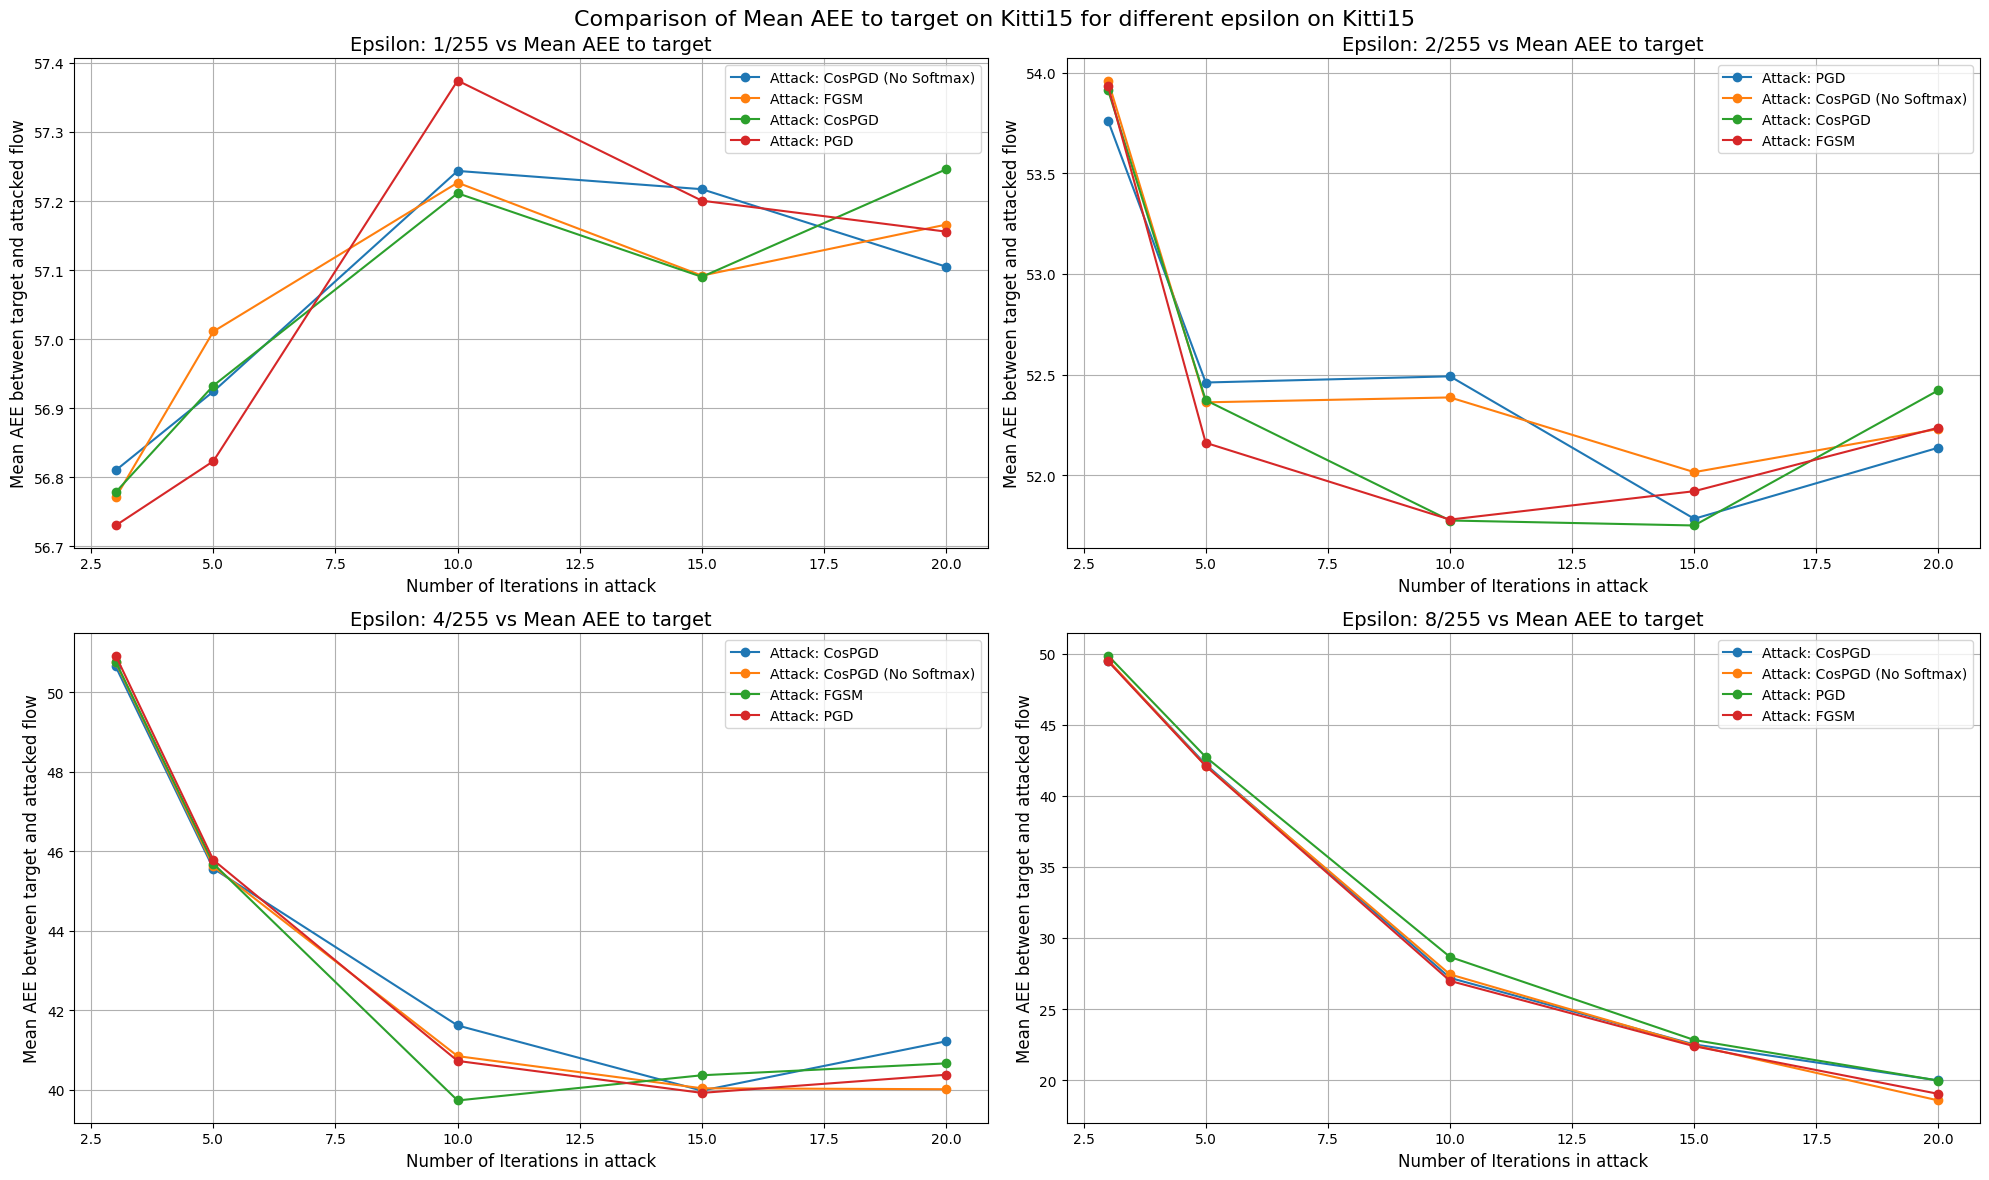

In [104]:

def plot_epsilon_vs_aee(runs_data, metric='mean_aee_target_attack_step_'):
    # Ensure `runs_data` is a DataFrame with necessary columns
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Get unique epsilon values
    epsilon_groups = runs_data.groupby("epsilon")

    # Create a single figure to hold all the subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    # Flatten the axes array to make it easier to iterate
    axes = axes.flatten()
    if len(epsilon_groups) == 1:
        axes = [axes]  # Ensure axes is always iterable
    fig.suptitle(
        'Comparison of Mean AEE to target on Kitti15 for different epsilon on Kitti15', fontsize=16)
    # Iterate over each epsilon group and plot the data in a subplot
    for idx, (epsilon, group) in enumerate(epsilon_groups):
        ax = axes[idx]  # Select the axis for the current subplot
        epsilon = float(epsilon)

        # Set the title for each subplot based on epsilon value
        if epsilon == 0.00392:
            eps_frac = '1/255'

        elif epsilon == 0.00784:
            eps_frac = '2/255'

        elif epsilon == 0.01568:
            eps_frac = '4/255'

        elif epsilon == 0.03137:
            eps_frac = '8/255'

        ax.set_title(
            f'Epsilon: {eps_frac} vs Mean AEE to target', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel('Mean AEE between target and attacked flow', fontsize=12)

        # Filter rows for the current epsilon value
        for _, row in group.iterrows():
            values = {}
            attack_type = row["attack_type"]
            no_softmax = row["no_softmax"]
            legend_label = f"Attack: {attack_type} {'(No Softmax)' if no_softmax == 'True' else ''}"
            for column, _ in row.items():
                if column.startswith(metric):
                    # Extract the step number from the column name using regex
                    # This extracts the last number in the column name
                    step_number = re.search(r'(\d+)$', column)
                    if step_number:
                        step_number = int(step_number.group(1))
                    else:
                        continue

                    # Extract the iterations and corresponding metric values
                    values[step_number] = row[column]

            # Sort the values by step number
            sorted_items = sorted(values.items())
            sorted_steps = [key for key, value in sorted_items]
            sorted_metrics = [value for key, value in sorted_items]

            # Plot the data with the step number in the label
            ax.plot(sorted_steps, sorted_metrics,
                    marker="o", label=legend_label)

        # Display the legend, grid for each subplot
        ax.legend(loc='best')
        ax.grid(True)

    # Adjust the layout to prevent overlapping
    plt.tight_layout()
    plt.show()


# Example Usage:
# Assuming `runs_data` is already loaded with the data from `load_mlflow_data`
plot_epsilon_vs_aee(data, metric='mean_aee_target_attack_step_')

In [42]:
expanded_df[expanded_df['run_id'] == 'd8eebaaf7f4342c3b9dfab5c27c11b37']

,run_id,attack_type,epsilon,iteration,metric_name,metric_value
25,d8eebaaf7f4342c3b9dfab5c27c11b37,PGD,0.03137,20,mean_aee_target_attack_step_20,14.606260
26,d8eebaaf7f4342c3b9dfab5c27c11b37,PGD,0.03137,5,mean_aee_target_attack_step_5,23.748399
27,d8eebaaf7f4342c3b9dfab5c27c11b37,PGD,0.03137,3,mean_aee_target_attack_step_3,28.805463
28,d8eebaaf7f4342c3b9dfab5c27c11b37,PGD,0.03137,15,mean_aee_target_attack_step_15,14.669454
29,d8eebaaf7f4342c3b9dfab5c27c11b37,PGD,0.03137,10,mean_aee_target_attack_step_10,17.212894
